In [1]:
#SIC contour 15% PCA basic - March 2024
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns  # Optional for aesthetics
import datetime
import numpy as np
from sklearn.decomposition import PCA

data_path  = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
fig_path   = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_fig15/'
shape_path = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15/'


In [2]:
ds = xr.open_mfdataset('/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_shape15_resample.nc')
# Drop NaN values along the 'time' dimension
ds = ds.dropna(dim='time')
ds

<xarray.Dataset>
Dimensions:  (time: 13677, dist: 1000)
Coordinates:
  * time     (time) datetime64[ns] 1978-10-25T12:00:00 ... 2024-03-06T12:00:00
  * dist     (dist) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999
Data variables:
    C15x     (time, dist) float64 dask.array<chunksize=(13677, 1000), meta=np.ndarray>
    C15y     (time, dist) float64 dask.array<chunksize=(13677, 1000), meta=np.ndarray>

In [3]:
# Assuming you have vectors x and y
x = np.array(ds.C15x.load())  # Example x vector
y = np.array(ds.C15y.load())  # Example y vector

# Stack vectors horizontally
data = np.hstack((x, y))

# Instantiate PCA model
npc = 10
pca = PCA(n_components=npc)  # Specify the number of principal components you want

# Fit PCA model
pca.fit(data)

# Transform data
transformed_data = pca.transform(data)

print("Original data shape:", data.shape)
print("Transformed data shape:", transformed_data.shape)


Original data shape: (13677, 2000)
Transformed data shape: (13677, 10)


In [4]:
ds['PC'] = xr.DataArray(transformed_data, 
                                    dims=('time', 'pca_components'), 
                                    coords={'time': ds.time, 'pca_components': np.arange(1,npc+1)})

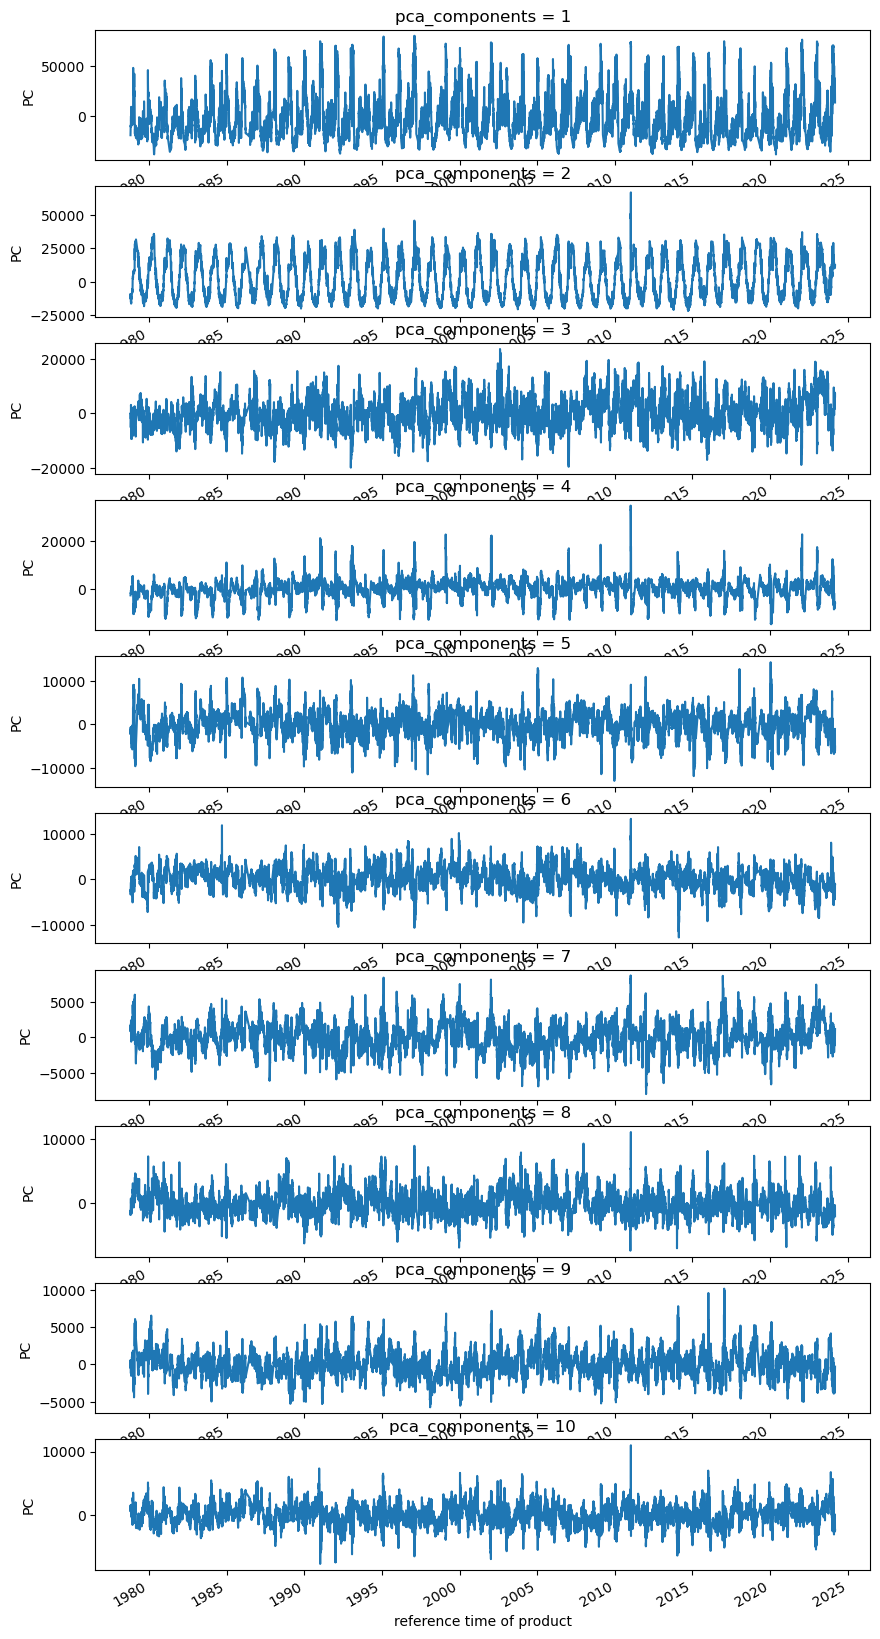

In [5]:
fig,axs = plt.subplots(npc,1,figsize = (10,20))
for i in np.arange(npc):
    ds.PC.isel(pca_components = i).plot(ax = axs[i])


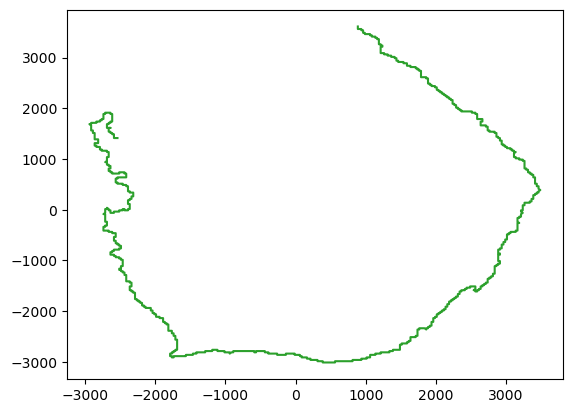

In [6]:
#Drop anomaly
dss = ds.isel(time = ds.PC.isel(pca_components = 2).argmax().data)
plt.plot(dss.C15x,dss.C15y,c = 'tab:green',label = "resampled")
